In [1518]:
import numpy as np
import pandas as pd
%matplotlib inline

In [1519]:
# Lendo os dados
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)
df.head()

,Cliente,Nº Cliente,UC,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,Lucile Confecções LTDA,7.005714e+09,3003858507,1246.0,1081.0,1184.0,1549.0,2045.0,4017.0,2386.0,...,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
1,CLL Hotel e Turismo,7.008529e+09,3001084033,7160.0,6520.0,6840.0,7440.0,6920.0,6920.0,7240.0,...,52317,48122,50739,48737,52874,56271,51096,53430,45995,51054
2,Academia Planeta Corpo,7.005369e+09,3011373971,440.0,600.0,680.0,760.0,560.0,520.0,320.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MD Predial,7.005492e+09,3001449459,960.0,920.0,1120.0,1040.0,1120.0,1240.0,1000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MD Predial,7.005492e+09,3011504476,1560.0,1280.0,1360.0,1680.0,1680.0,2920.0,1960.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1520]:
# Removendo dados desnecessários
df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

In [1521]:
# Ajustando o dataset
df_test = df.head()
df_test

,UC,2019-06-01 00:00:00,2019-07-01 00:00:00,2019-08-01 00:00:00,2019-09-01 00:00:00,2019-10-01 00:00:00,2019-11-01 00:00:00,2019-12-01 00:00:00,2020-01-01 00:00:00,2020-02-01 00:00:00,...,2022-05-01 00:00:00,2022-06-01 00:00:00,2022-07-01 00:00:00,2022-08-01 00:00:00,2022-09-01 00:00:00,2022-10-01 00:00:00,2022-11-01 00:00:00,2022-12-01 00:00:00,2023-01-01 00:00:00,2023-02-01 00:00:00
0,3003858507,1246.0,1081.0,1184.0,1549.0,2045.0,4017.0,2386.0,4239.0,2854.0,...,2478.0,817.0,601.0,638.0,686.0,1216.0,1335.0,1317.0,2367.0,3056.0
1,3001084033,7160.0,6520.0,6840.0,7440.0,6920.0,6920.0,7240.0,6560.0,7440.0,...,6800.0,6760.0,6280.0,5560.0,6360.0,7440.0,7240.0,7960.0,5880.0,7560.0
2,3011373971,440.0,600.0,680.0,760.0,560.0,520.0,320.0,440.0,280.0,...,680.0,840.0,800.0,760.0,840.0,920.0,360.0,680.0,800.0,480.0
3,3001449459,960.0,920.0,1120.0,1040.0,1120.0,1240.0,1000.0,1120.0,1200.0,...,800.0,720.0,880.0,680.0,800.0,1000.0,840.0,880.0,840.0,760.0
4,3011504476,1560.0,1280.0,1360.0,1680.0,1680.0,2920.0,1960.0,2280.0,2480.0,...,1840.0,1600.0,1480.0,1440.0,1720.0,2280.0,2000.0,2160.0,2120.0,2680.0


In [1522]:
# Corrigindo os dados para uso das fórmulas
df_test_transpose1 = df_test.transpose()
df_test_transpose = df_test_transpose1.rename(columns=df_test_transpose1.iloc[0])
df_test_transpose.drop("UC", inplace=True, axis=0)
df_test_transpose.dropna(inplace=True)
df_test_transpose

,3003858507,3001084033,3011373971,3001449459,3011504476
2019-06-01 00:00:00,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01 00:00:00,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01 00:00:00,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01 00:00:00,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01 00:00:00,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01 00:00:00,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01 00:00:00,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01 00:00:00,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01 00:00:00,2854.0,7440.0,280.0,1200.0,2480.0
2020-03-01 00:00:00,3208.0,7440.0,320.0,1360.0,2240.0


In [1523]:
# transformando índice em datetime
df_test_transpose.index
some_dates = np.array(df_test_transpose.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(some_dates)
df_test_transpose["idx"] = idx
df_test_transpose.set_index("idx", inplace=True)
df_test_transpose

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [1524]:
df_test_transpose.columns

Index([3003858507, 3001084033, 3011373971, 3001449459, 3011504476], dtype='object')

In [1525]:
df_test_transpose.index.freq = "MS"
df_test_transpose.index

DatetimeIndex(['2019-06-01', '2019-07-01', '2019-08-01', '2019-09-01',
               '2019-10-01', '2019-11-01', '2019-12-01', '2020-01-01',
               '2020-02-01', '2020-03-01', '2020-04-01', '2020-05-01',
               '2020-06-01', '2020-07-01', '2020-08-01', '2020-09-01',
               '2020-10-01', '2020-11-01', '2020-12-01', '2021-01-01',
               '2021-02-01', '2021-03-01', '2021-04-01', '2021-05-01',
               '2021-06-01', '2021-07-01', '2021-08-01', '2021-09-01',
               '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-01',
               '2022-02-01', '2022-03-01', '2022-04-01', '2022-05-01',
               '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01',
               '2022-10-01', '2022-11-01', '2022-12-01', '2023-01-01',
               '2023-02-01'],
              dtype='datetime64[s]', name='idx', freq='MS')

In [1526]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

span = 6
alpha = 2 / (span + 1)

df_test_transpose["SES"] = (
    SimpleExpSmoothing(df_test_transpose[3003858507].astype(float))
    .fit(smoothing_level=alpha, optimized=False)
    .fittedvalues
)

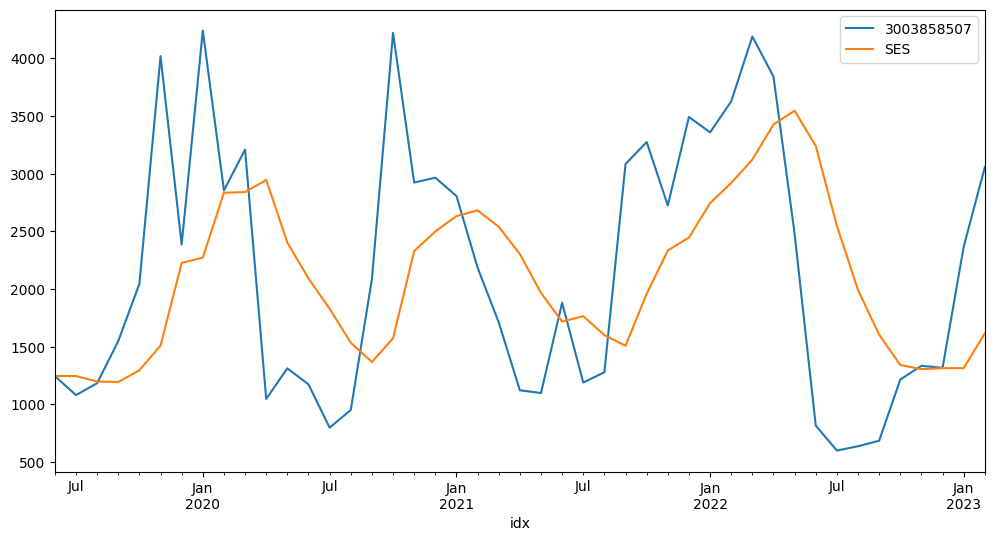

In [1527]:
df_test_transpose[[3003858507, "SES"]].plot(figsize=(12, 6)).autoscale(
    axis="x", tight=True
)

In [1528]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df_test_transpose["HWadd"] = (
    ExponentialSmoothing(
        df_test_transpose[3003858507].astype(float),
        trend="add",
        seasonal="add",
        seasonal_periods=6,
    )
    .fit()
    .fittedvalues
)
df_test_transpose["HWmul"] = (
    ExponentialSmoothing(
        df_test_transpose[3003858507].astype(float),
        trend="mul",
        seasonal="mul",
        seasonal_periods=6,
    )
    .fit()
    .fittedvalues
)

/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


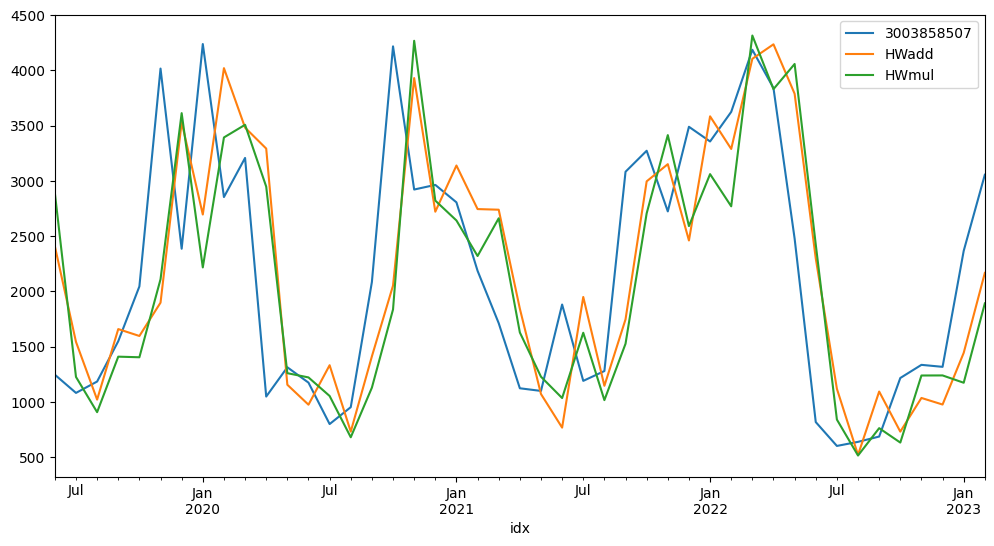

In [1529]:
df_test_transpose[[3003858507, "HWadd", "HWmul"]].plot(figsize=(12, 6)).autoscale(
    axis="x", tight=True
)

In [1530]:
df_test_transpose.info()
df_test_transpose.drop(['SES', 'HWadd', 'HWmul'],axis=1, inplace=True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45 entries, 2019-06-01 to 2023-02-01
Freq: MS
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   3003858507  45 non-null     object 
 1   3001084033  45 non-null     object 
 2   3011373971  45 non-null     object 
 3   3001449459  45 non-null     object 
 4   3011504476  45 non-null     object 
 5   SES         45 non-null     float64
 6   HWadd       45 non-null     float64
 7   HWmul       45 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.2+ KB


In [1531]:
train_data = df_test_transpose.loc[:'2022-09-01']
test_data = df_test_transpose.loc['2022-09-01':]
test_data

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2022-09-01,686.0,6360.0,840.0,800.0,1720.0
2022-10-01,1216.0,7440.0,920.0,1000.0,2280.0
2022-11-01,1335.0,7240.0,360.0,840.0,2000.0
2022-12-01,1317.0,7960.0,680.0,880.0,2160.0
2023-01-01,2367.0,5880.0,800.0,840.0,2120.0
2023-02-01,3056.0,7560.0,480.0,760.0,2680.0


In [1532]:
fitted_model = ExponentialSmoothing(train_data[3001084033].astype(float), trend='mul',seasonal='add',seasonal_periods=12).fit()

/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


In [1533]:
test_predictions = fitted_model.forecast(6)

2022-10-01    6233.744229
2022-11-01    6759.132747
2022-12-01    6934.831020
2023-01-01    6608.338430
2023-02-01    6752.201303
2023-03-01    6658.726990
Freq: MS, dtype: float64

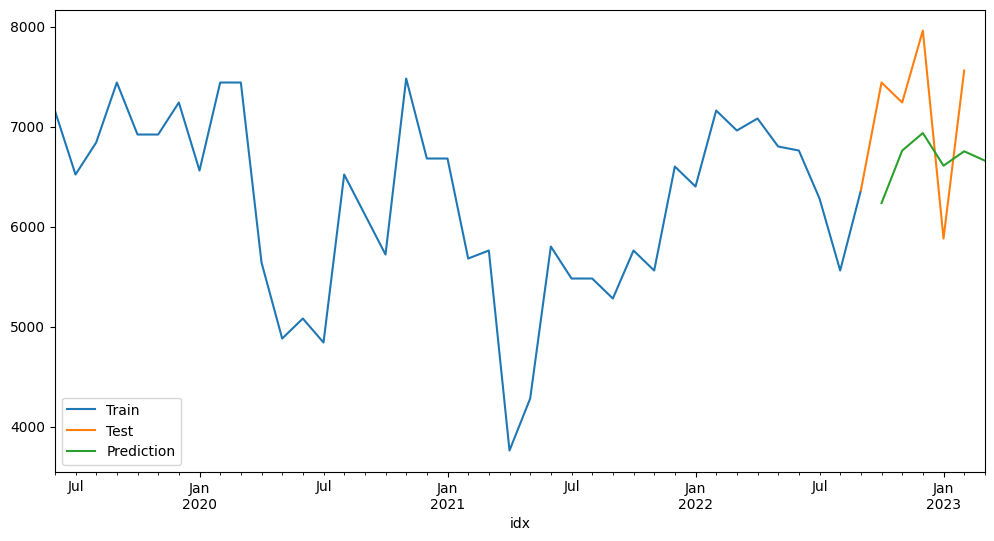

In [1534]:
train_data[3001084033].plot(legend=True,label='Train',figsize=(12,6))
test_data[3001084033].plot(legend=True,label='Test',figsize=(12,6))
test_predictions.plot(legend=True,label='Prediction',figsize=(12,6))
test_predictions

In [1535]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

test_data.astype(float).describe()

,3003858507,3001084033,3011373971,3001449459,3011504476
count,6.000000,6.000000,6.000000,6.000000,6.000000
mean,1662.833333,7073.333333,680.000000,853.333333,2160.000000
std,873.808083,789.700365,219.089023,82.623645,317.993711
min,686.000000,5880.000000,360.000000,760.000000,1720.000000
25%,1241.250000,6580.000000,530.000000,810.000000,2030.000000
50%,1326.000000,7340.000000,740.000000,840.000000,2140.000000
75%,2109.000000,7530.000000,830.000000,870.000000,2250.000000
max,3056.000000,7960.000000,920.000000,1000.000000,2680.000000


In [1536]:
mean_absolute_error(test_data[3001084033], test_predictions)

706.2379811262041

In [1537]:
np.sqrt(mean_squared_error(test_data[3001084033], test_predictions))

813.7020333364834